# ⚙️ 03 — Baseline Modeling

This notebook builds and evaluates the `baseline prediction model` for Taiwan’s air quality dataset.

The purpose is to establish `a reference performance benchmark` before moving on to more advanced models.

## 🧠 01 — Notebook Metadata

Basic setup and context for baseline model training.

💡 Content:

- Import all necessary libraries (`pandas`, `sklearn`, `matplotlib`, `seaborn`)

- Load configuration paths from `config.py`

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.config import PROCESSED_DIR, MODEL_DIR
from src.features.feature_engineering import (
    add_rolling_features,
    clip_pollutants,
    handle_outliers_iqr,
    log_transform_features,
)
from src.modeling.train_baseline import load_cleaned_data
from src.utils.emoji_log import success, info

success("Modules imported successfully. Ready for baseline modeling!")

✅ Modules imported successfully. Ready for baseline modeling!


## 📂 02 — Load and Prepare Data

Load the processed and feature-engineered dataset (e.g., `Taiwan` or per-city data)
and prepare it for modeling.

💡 Content:

- Use `load_cleaned_data("Taiwan")`

- Apply `log_transform_features()` if not yet transformed

- Inspect shape, columns, and basic statistics (`df.shape`, `df.head()`, `df.describe()`)

In [2]:
df = load_cleaned_data("Taiwan")

# clip the pollutants
df = clip_pollutants(df.copy())

# Add the rolling columns
df = add_rolling_features(df)

# Set iqr
df = handle_outliers_iqr(df)

# smooth the skewes
df = log_transform_features(df)

📂 Loading CSV: C:\Users\dinni\OneDrive\桌面\air_pollution\data\processed\Taiwan.csv
✅ Read CSV successfully! Shape: (5823862, 25)
✅ The pollutants limit has been set.
⚠️ Skipping nox due to NO + NO2 already exist.
✅ Rolling features added.
✅ IQR has been set.
✅ Pollutants skewes has been smoothed.


In [3]:
df.shape

(5823862, 38)

In [4]:
df.head()

,date,sitename,county,aqi,status,so2,co,o3,o3_8hr,pm10,...,o3_rolling_3d,o3_rolling_7d,pm10_rolling_3d,pm10_rolling_7d,pm2.5_rolling_3d,pm2.5_rolling_7d,no2_rolling_3d,no2_rolling_7d,no_rolling_3d,no_rolling_7d
0,2024-08-31 23:00:00,Hukou,Hsinchu_County,62.0,Moderate,0.641854,0.157004,3.583519,40.2,2.944439,...,35.0,35.0,18.0,18.0,17.0,17.0,2.3,2.3,0.3,0.3
54,2024-08-31 23:00:00,Magong,Penghu_County,74.0,Moderate,0.916291,0.207014,4.082609,62.8,2.890372,...,58.3,58.3,17.0,17.0,19.0,19.0,1.0,1.0,1.7,1.7
62,2024-08-31 23:00:00,Pingtung (Liuqiu),Pingtung_County,43.0,Good,0.336472,0.165514,3.618993,42.2,3.091042,...,36.3,36.3,21.0,21.0,9.0,9.0,3.8,3.8,0.3,0.3
61,2024-08-31 23:00:00,Tainan (Madou),Tainan_City,41.0,Good,0.530628,0.231112,3.173878,38.5,2.944439,...,22.9,22.9,18.0,18.0,7.0,7.0,12.5,12.5,1.1,1.1
60,2024-08-31 23:00:00,Kaohsiung (Hunei),Kaohsiung_City,37.0,Good,0.916291,0.165514,3.555348,40.8,2.639057,...,34.0,34.0,13.0,13.0,5.0,5.0,4.5,4.5,1.3,1.3


In [5]:
df.describe()

,date,aqi,so2,co,o3,o3_8hr,pm10,pm2.5,no2,no,...,o3_rolling_3d,o3_rolling_7d,pm10_rolling_3d,pm10_rolling_7d,pm2.5_rolling_3d,pm2.5_rolling_7d,no2_rolling_3d,no2_rolling_7d,no_rolling_3d,no_rolling_7d
count,5823862,5.823862e+06,5.823841e+06,5.823841e+06,5.823841e+06,5.823841e+06,5.823607e+06,5.823791e+06,5.823837e+06,5.823837e+06,...,5.823841e+06,5.823841e+06,5.823607e+06,5.823607e+06,5.823791e+06,5.823791e+06,5.823837e+06,5.823837e+06,5.823837e+06,5.823837e+06
mean,2020-11-26 06:17:31.644631808,5.423027e+01,9.805545e-01,2.697061e-01,3.224398e+00,3.013913e+01,3.341305e+00,2.630785e+00,2.261632e+00,9.606313e-01,...,3.020793e+01,3.020763e+01,3.436091e+01,3.436037e+01,1.681923e+01,1.681913e+01,1.124373e+01,1.124357e+01,3.456005e+00,3.455955e+00
min,2016-11-25 13:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2019-02-09 20:00:00,3.200000e+01,6.931472e-01,1.739533e-01,2.833213e+00,1.800000e+01,2.944439e+00,2.197225e+00,1.808289e+00,5.877867e-01,...,1.646667e+01,1.771429e+01,1.833333e+01,1.871429e+01,8.333333e+00,8.571429e+00,5.300000e+00,5.600000e+00,8.021264e-01,9.000000e-01
50%,2021-02-02 11:00:00,4.700000e+01,9.932518e-01,2.468601e-01,3.367296e+00,2.860000e+01,3.401197e+00,2.708050e+00,2.312535e+00,8.754687e-01,...,2.816667e+01,2.849784e+01,2.866667e+01,2.885714e+01,1.366667e+01,1.371429e+01,9.217967e+00,9.471429e+00,1.466667e+00,1.571429e+00
75%,2022-09-12 13:00:00,7.000000e+01,1.252763e+00,3.435897e-01,3.751854e+00,4.000000e+01,3.828641e+00,3.135494e+00,2.772589e+00,1.308333e+00,...,4.133333e+01,4.061429e+01,4.475105e+01,4.485714e+01,2.233333e+01,2.218958e+01,1.500000e+01,1.488571e+01,2.833333e+00,2.957143e+00
max,2024-08-31 23:00:00,5.000000e+02,1.749200e+00,5.538851e-01,4.394449e+00,1.358000e+02,4.460144e+00,3.784190e+00,3.429137e+00,1.879465e+00,...,1.565582e+02,1.366571e+02,1.000000e+03,9.285714e+02,3.586667e+02,1.882810e+02,1.208833e+02,8.242857e+01,2.946667e+02,2.367143e+02
std,NaN,2.978873e+01,4.003616e-01,1.237822e-01,7.337454e-01,1.578343e+01,6.774754e-01,7.189771e-01,6.930268e-01,5.205350e-01,...,1.756278e+01,1.615450e+01,2.330810e+01,2.237542e+01,1.206548e+01,1.160489e+01,8.298150e+00,7.828619e+00,7.842026e+00,7.239352e+00


## 🧩 03 — Define Features and Target

Identify the `predictors (X)` and the `target (y)` variable for modeling.

💡 Content:

- Target variable: `aqi`

- Exclude non-numeric or categorical columns (`date`, `county`, `sitename`)

- Verify feature matrix and target vector shape

In [6]:
# The target is aqi
df.dropna(subset=["aqi"], inplace=True)
y = df["aqi"]

In [7]:
# Establish X
X = df.drop(columns=["date", "county", "sitename", "status", "aqi", "season"])

# Fill the na with 0
X = X.fillna(0)

In [8]:
# Check the X and y shape
info(f"Features shape: {X.shape}, Target shape: {y.shape}")

💬 Features shape: (5823862, 32), Target shape: (5823862,)


## ✂️ 04 — Train-Test Split

Divide the dataset into training and testing sets for model validation.

💡 Content:

- Use `train_test_split` (e.g., 80% train / 20% test)

- Print sample sizes

- Check that distributions of `aqi` in both sets are consistent

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
X_train.shape

(4659089, 32)

In [12]:
X_test.shape

(1164773, 32)

In [13]:
y_train.shape

(4659089,)

In [14]:
# StandardScaler
from sklearn.preprocessing import StandardScaler

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
import joblib
joblib.dump(scaler, "models/standard_scaler.pkl")

['models/standard_scaler.pkl']

In [17]:
data_split = {
    "X_train": X_train_scaled,
    "X_test": X_test_scaled,
    "y_train": y_train,
    "y_test": y_test,
}

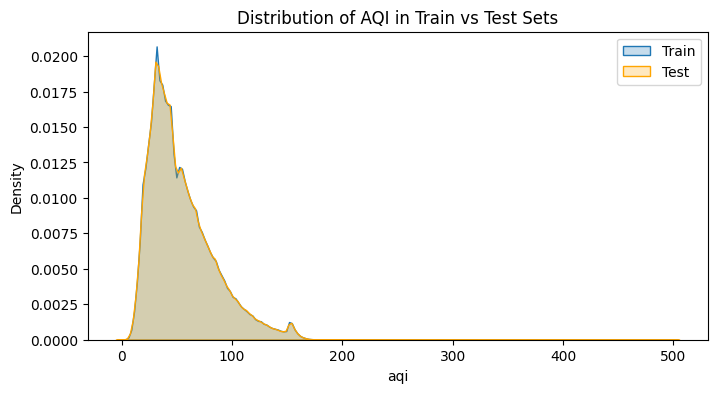

In [18]:
plt.figure(figsize=(8,4))
sns.kdeplot(y_train, label="Train", fill=True)
sns.kdeplot(y_test, label="Test", fill=True, color="orange")
plt.title("Distribution of AQI in Train vs Test Sets")
plt.legend()
plt.show()

## 🧮 05 — Build Baseline Model

Train a simple `Linear Regression` as the baseline.

💡 Content:

- `from sklearn.linear_model import LinearRegression`

- Fit the model on training data

- Print regression coefficients

- Plot predicted vs actual values

In [19]:
from sklearn.linear_model import LinearRegression

In [20]:
# Establish and train the baseline model
model = LinearRegression()

model.fit(X_train_scaled, y_train)

print("Baseline model has been trained.")

Baseline model has been trained.


In [21]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

In [22]:
# Check weight and intercept
coef_df = pd.DataFrame(
    {"Feature": X_train_scaled_df.columns, "Coefficient": model.coef_}
).sort_values(by="Coefficient", ascending=False)
print(f"Intercept: {model.intercept_:.3f}")

Intercept: 54.237


In [23]:
coef_df.head(10)

,Feature,Coefficient
26,pm2.5_rolling_3d,15.204459
3,o3_8hr,8.052679
10,co_8hr,6.506240
24,pm10_rolling_3d,4.400905
23,o3_rolling_7d,3.452242
29,no2_rolling_7d,3.342392
5,pm2.5,2.534389
27,pm2.5_rolling_7d,2.332108
4,pm10,1.204660
1,co,0.827016


In [24]:
coef_df.tail(10)

,Feature,Coefficient
11,longitude,-0.340411
17,hour,-0.421183
14,month,-0.724045
12,latitude,-1.161088
22,o3_rolling_3d,-1.384602
21,co_rolling_7d,-1.697447
25,pm10_rolling_7d,-2.110725
20,co_rolling_3d,-2.444430
28,no2_rolling_3d,-3.039554
2,o3,-3.396459


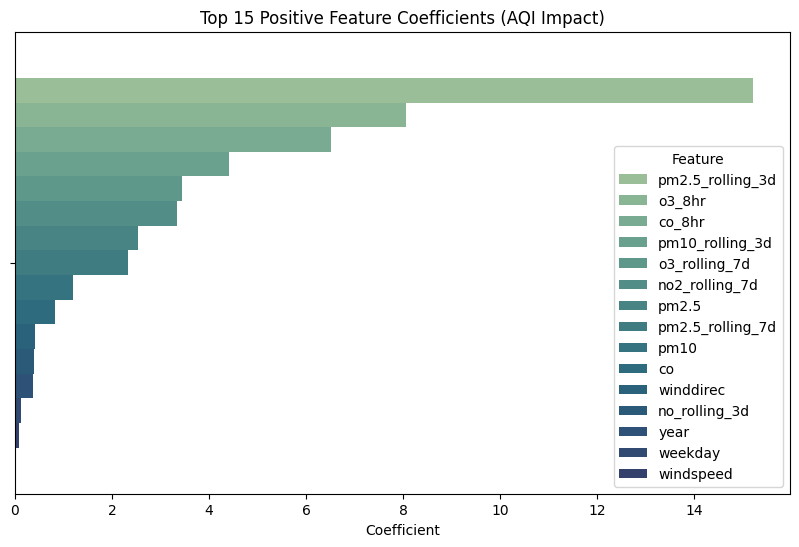

In [25]:
plt.figure(figsize=(10,6))
sns.barplot(data=coef_df.head(15), x="Coefficient", hue="Feature", palette="crest")
plt.title("Top 15 Positive Feature Coefficients (AQI Impact)")
plt.show()

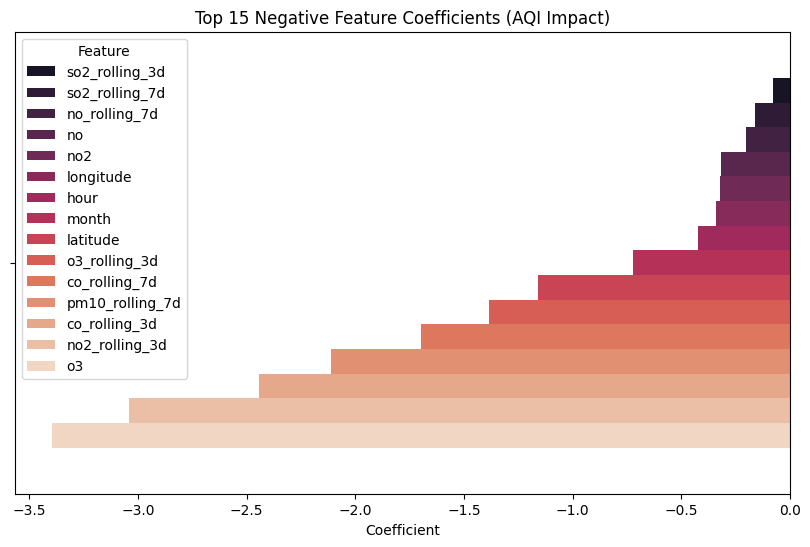

In [26]:
plt.figure(figsize=(10,6))
sns.barplot(data=coef_df.tail(15), x="Coefficient", hue="Feature", palette="rocket")
plt.title("Top 15 Negative Feature Coefficients (AQI Impact)")
plt.show()

In [27]:
# Compute Residuals
y_test = data_split["y_test"]
y_pred = model.predict(data_split["X_test"])

residuals = y_test - y_pred
residual_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Residual": residuals
})

residual_df.sort_values("Residual")

,Actual,Predicted,Residual
5387392,79.0,700.286069,-621.286069
5387515,52.0,671.751547,-619.751547
5387397,75.0,584.521938,-509.521938
5387317,50.0,515.936679,-465.936679
3540255,68.0,517.503614,-449.503614
...,...,...,...
4097786,380.0,40.630630,339.369370
4064883,385.0,29.457102,355.542898
4930215,500.0,140.255355,359.744645
4097942,500.0,83.453070,416.546930


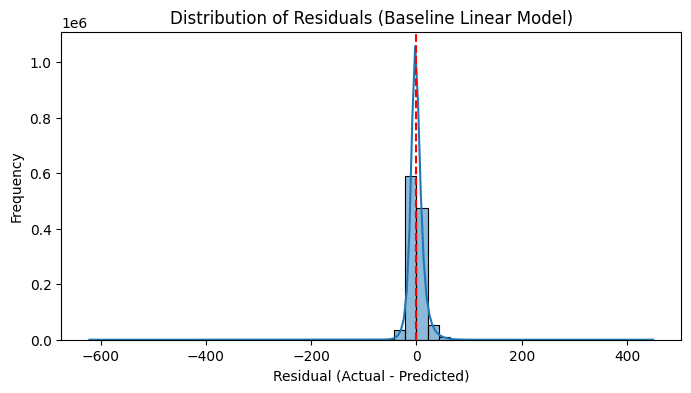

In [28]:
plt.figure(figsize=(8,4))
sns.histplot(residual_df["Residual"], bins=50, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.title("Distribution of Residuals (Baseline Linear Model)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()

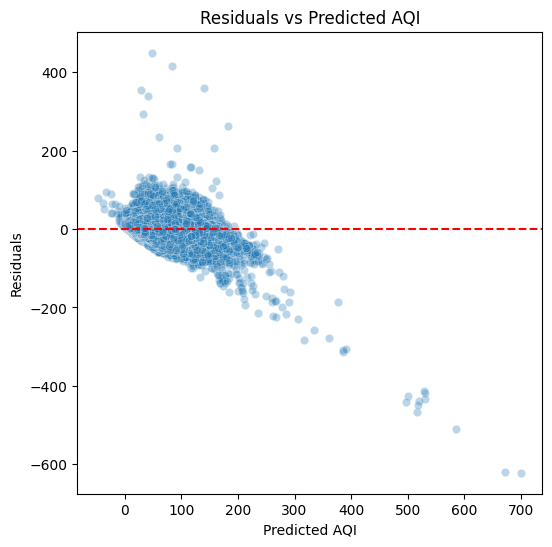

In [29]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.3)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted AQI")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted AQI")
plt.show()

## 📊 06 — Evaluate Performance

Evaluate baseline model’s predictive accuracy and compare its numerical metrics.

🧩 Contents

1️⃣ Import evaluation metrics

2️⃣ Compute model scores (MAE, RMSE, R²)

3️⃣ Visualize predicted vs actual AQI

4️⃣ Visualize error distribution by AQI range

5️⃣ (Optional) Save evaluation results for model tracking

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [31]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

info(f"MAE = {mae:.3f}")
info(f"RMSE = {rmse:.3f}")
info(f"R² = {r2:.3f}")

💬 MAE = 9.254
💬 RMSE = 13.053
💬 R² = 0.808


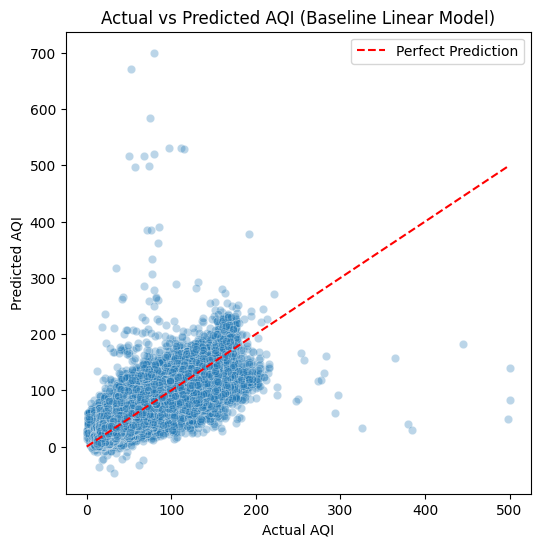

In [32]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)
plt.plot([0, 500], [0, 500], color="red", linestyle="--", label="Perfect Prediction")
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI (Baseline Linear Model)")
plt.legend()
plt.show()


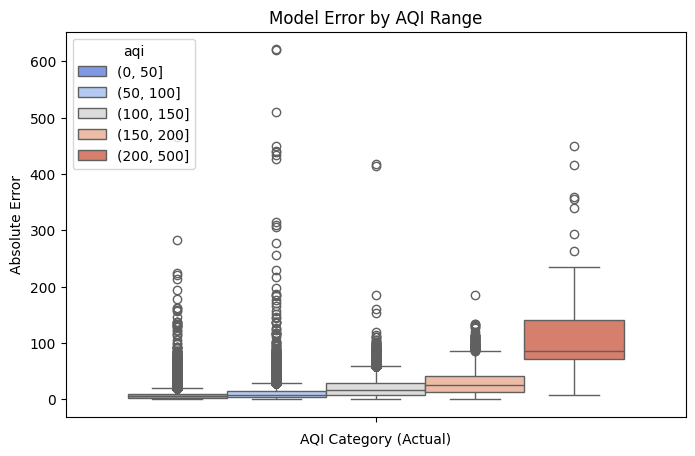

In [33]:
error_abs = np.abs(y_test - y_pred)
aqi_bins = pd.cut(y_test, bins=[0, 50, 100, 150, 200, 500])

plt.figure(figsize=(8,5))
sns.boxplot(hue=aqi_bins, y=error_abs, palette="coolwarm")
plt.xlabel("AQI Category (Actual)")
plt.ylabel("Absolute Error")
plt.title("Model Error by AQI Range")
plt.show()

In [34]:
import json
import datetime

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")
metrics = {"MAE": mae, "RMSE": rmse, "r2": r2}

output_path = MODEL_DIR / f"baseline_metrics_{timestamp}.json"
with open(output_path, "w") as f:
    json.dump(metrics, f, indent=4)

success(f"Baseline metrics saved at {output_path}")

✅ Baseline metrics saved at C:\Users\dinni\OneDrive\桌面\air_pollution\models\baseline_metrics_20251110_1947.json


### 📊Summary
- Linear Regression Model has good performance in mid-low pollution area.

- Significant increase in error in high-pollution areas (heteroscedasticity)

- Get ready to move into nonlinear regression comparison.

## 💾 07 — Save Model and Metrics

Store the trained baseline model for future comparison.

💡 Content:

- Save using:

    ```
    import joblib
    joblib.dump(model, MODEL_DIR / "baseline_linear.pkl")
    ```

- Save metrics summary as `.json` or `.csv` for tracking progress.

## 📊 08 — Model Interpretation

Explore which features influence AQI the most.

💡 Content:

- Use regression coefficients or `feature_importances_` (for tree models)

- Plot bar chart of top predictors

- Discuss correlation vs model weight differences

## ✅ 09 — Summary and Next Steps

Conclude baseline results and outline improvement ideas.

💡 Content:
### ✅ Baseline Summary
- Model: Linear Regression  
- MAE: 9.254
- RMSE: 13.053
- R²: 0.808
- Key Features: PM2.5_rolling_3d, o3_8hr, co_8hr, PM10_rolling_3d

### 🚀 Next Steps
- Try non-linear models (RandomForest, XGBoost)
- Add weather-based features (wind speed, direction)
- Perform hyperparameter tuning
